# C5G7 Infinite Pincell Array

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('spawn')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
import pandas as pd
from igakit import cad

from ttnte.xs.benchmarks import c5g7
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import power, LinearSolverOptions
from ttnte.cad import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = c5g7()

In [3]:
# Create quarter circle NURBS surface
radius = 0.54 # cm
pitch = 1.26 # cm
c0 = cad.circle(radius=radius, angle=np.pi / 2)
c1 = c0.slice(0, 0, 0.5)
c2 = c0.slice(0, 0.5, 1)
l0 = cad.line(p0=(0, 0), p1=(0, 0))

# Create water patch
l1 = cad.line(p0=(pitch / 2, 0), p1=(pitch / 2, pitch / 2))
l2 = cad.line(p0=(pitch / 2, pitch / 2), p1=(0, pitch / 2))

# Create NURBS surfaces
fuel = [Patch(cad.ruled(l0, c1), "UO2"), Patch(cad.ruled(l0, c2), "UO2")]
water = [Patch(cad.ruled(c1, l1), "Water"), Patch(cad.ruled(c2, l2), "Water")]

# Initialize IGA mesh and add the patches
mesh = IGAMesh()
for patch in fuel + water:
    mesh.add_patch(patch)

# Refine each patch to have 6 knot spans with degree 2
mesh.refine(10, 2)

# Connect patches
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=4, reflective_boundaries=True)
  -> Patch(material=UO2, source=None, id=0, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=UO2, source=None, id=1, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Water, source=None, id=2, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Water, source=None, id=3, name=None, shape=(12, 12), backend=geomdl)

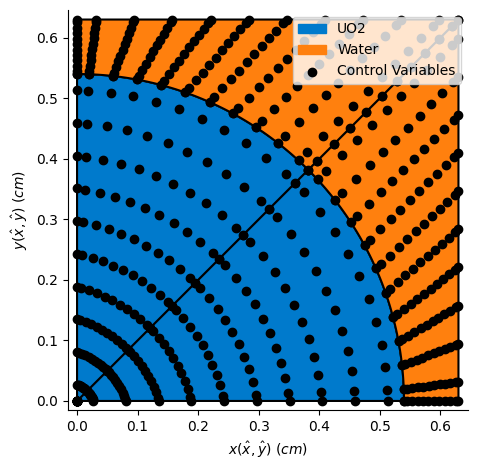

In [4]:
# Plot final mesh
ax = mesh.plot(plot_boundaries=True)
plt.tight_layout()
plt.savefig("./figs/pincell.png", dpi=300, transparent=True)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save COO information
assembler.save_info("./coo_info.csv")

# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=2,
)
tts = assembler.build(use_tt=False, eps=1e-5)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 1024, G = 7, P = 4, A = 12, B = 12
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 26.57 s)
Step            Shape                     Compression
H               4128768,4128768             99488.38
S               4128768,4128768           1048507.89
F               4128768,4128768           1048573.94
B_out           4128768,4128768           1782530.05
B_in            4128768,4128768           1775084.99
Running TTAssembler.build()
Discretization: N = 1024, G = 7, P = 4, A = 12, B = 12
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 5.37 s)
Step            Ranks                     Compression
H               3,3,3,4,12,17             450542478.01
S               1,1,1,2,4,9               2356472933.07
F               1,1,1,1,2,7               4692189704.88
B_out           4,28,46,46,48,7           31171553.64
B_in            8,32,49,49,49,8           25041572.88


## Solve

In [6]:
# COO operators only
psi, k = power(
    T=(mats.H - mats.S + mats.B_out - mats.B_in).combine(),
    F=mats.F,
    tol=1e-8,
    maxiter=1000,
    gpu_idx=0,
    lsoptions=LinearSolverOptions(
        tol=1e-10,
        maxiter=10,
        restart=75,
    )
)
psi = psi.reshape(assembler.discretization)

Running power iteration on GPU 0


-- (0): k = 0.972654, Angular Flux L2-Error = 0.853403585629, Elapsed Time = 7.050 s


-- (1): k = 0.714157, Angular Flux L2-Error = 0.418228276535, Elapsed Time = 14.074 s


-- (2): k = 0.816561, Angular Flux L2-Error = 0.192835213956, Elapsed Time = 21.084 s


-- (3): k = 0.983004, Angular Flux L2-Error = 0.099751226068, Elapsed Time = 28.095 s


...

-- (122): k = 1.325380, Angular Flux L2-Error = 0.000000012274, Elapsed Time = 862.853 s


-- (123): k = 1.325380, Angular Flux L2-Error = 0.000000011237, Elapsed Time = 869.868 s


-- (124): k = 1.325380, Angular Flux L2-Error = 0.000000010299, Elapsed Time = 876.882 s


-- (125): k = 1.325380, Angular Flux L2-Error = 0.000000009561, Elapsed Time = 883.897 s


-- Converged!


In [7]:
# Use both COO and TT operators
psi, k = power(
    T=(tts.H - tts.S).round(1e-5) + (mats.B_out - mats.B_in).combine(),
    F=tts.F,
    tol=1e-8,
    maxiter=1000,
    gpu_idx=0,
    lsoptions=LinearSolverOptions(
        tol=1e-10,
        maxiter=10,
        restart=75,
    )
)
psi = psi.reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Running power iteration on GPU 0


-- (0): k = 0.972656, Angular Flux L2-Error = 0.853402551472, Elapsed Time = 23.921 s


-- (1): k = 0.714158, Angular Flux L2-Error = 0.418255857866, Elapsed Time = 47.843 s


-- (2): k = 0.816567, Angular Flux L2-Error = 0.192814988323, Elapsed Time = 71.748 s


-- (3): k = 0.983340, Angular Flux L2-Error = 0.099918320804, Elapsed Time = 95.659 s


...

-- (122): k = 1.325382, Angular Flux L2-Error = 0.000000012242, Elapsed Time = 2940.424 s


-- (123): k = 1.325382, Angular Flux L2-Error = 0.000000011188, Elapsed Time = 2964.330 s


-- (124): k = 1.325382, Angular Flux L2-Error = 0.000000010302, Elapsed Time = 2988.235 s


-- (125): k = 1.325382, Angular Flux L2-Error = 0.000000009546, Elapsed Time = 3012.140 s


-- Converged!


## Plotting and Comparison to OpenMC

In [8]:
# Get OpenMC solution
k_mc = [1.325593, 0.000032]
phi_mc = np.load("./openmc/data/mesh_flux.npy")
phi_mc_stdev = np.load("./openmc/data/mesh_stdev.npy")

# Ensure OpenMC solution is normalized
phi_mc_stdev /= np.linalg.norm(phi_mc.flatten(), 2)
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print(f"TDIGA k = {k}")
print(f"OpenMC k = {k_mc[0]} +/- {k_mc[1]}")
print(f"Error = {(k - k_mc[0]) * 1e5} pcm or {(k - k_mc[0]) / k_mc[1]} stdevs from OpenMC")

TDIGA k = 1.3253823241118452
OpenMC k = 1.325593 +/- 3.2e-05
Error = -21.067588815482097 pcm or -6.583621504838155 stdevs from OpenMC


<Figure size 640x480 with 0 Axes>

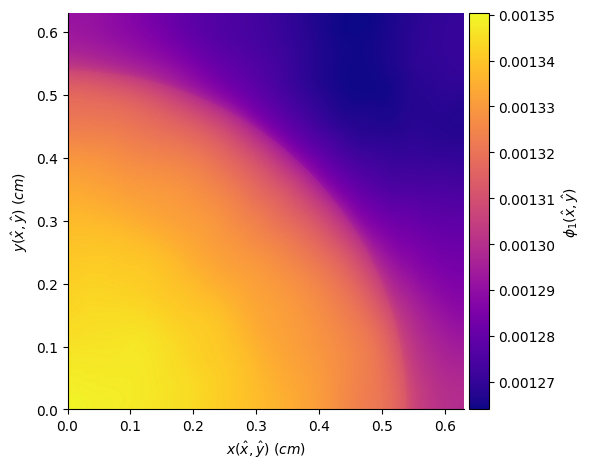

<Figure size 640x480 with 0 Axes>

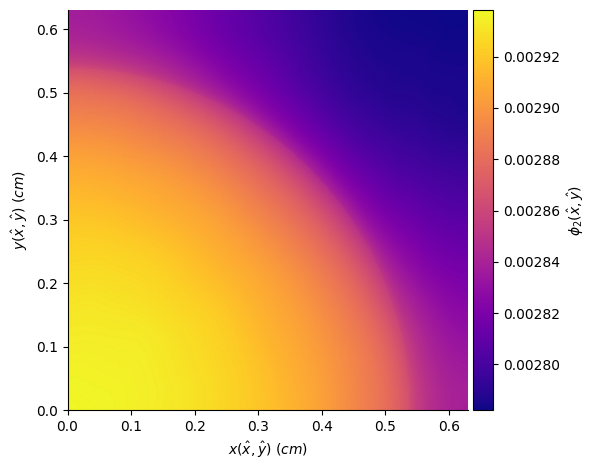

<Figure size 640x480 with 0 Axes>

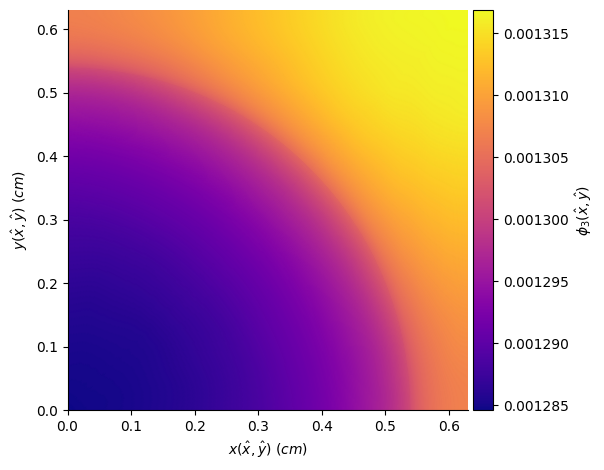

<Figure size 640x480 with 0 Axes>

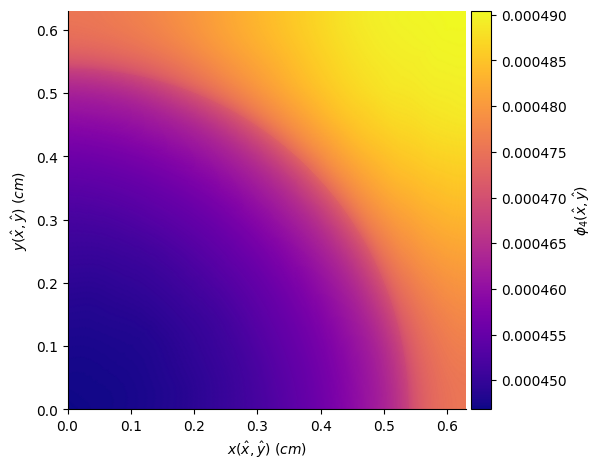

<Figure size 640x480 with 0 Axes>

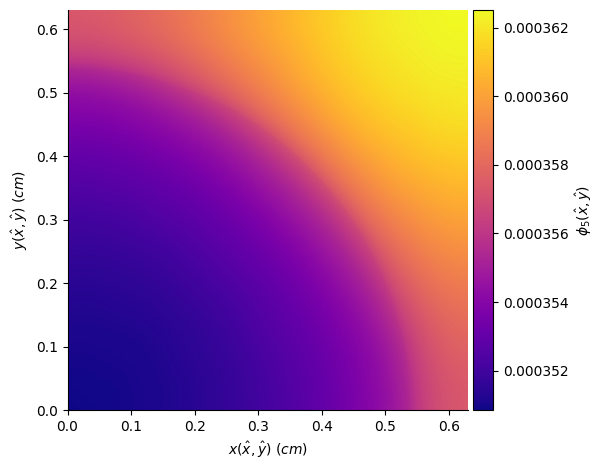

<Figure size 640x480 with 0 Axes>

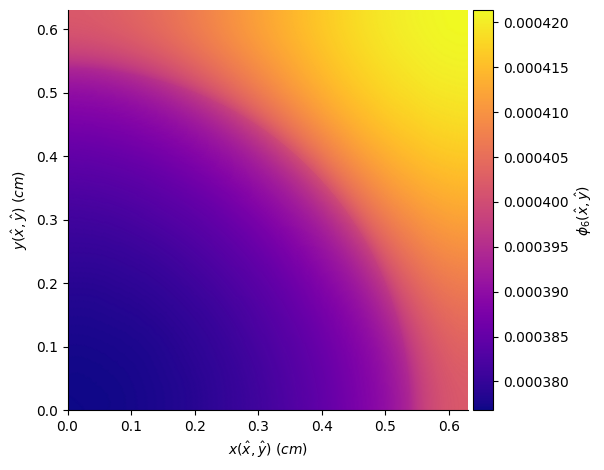

<Figure size 640x480 with 0 Axes>

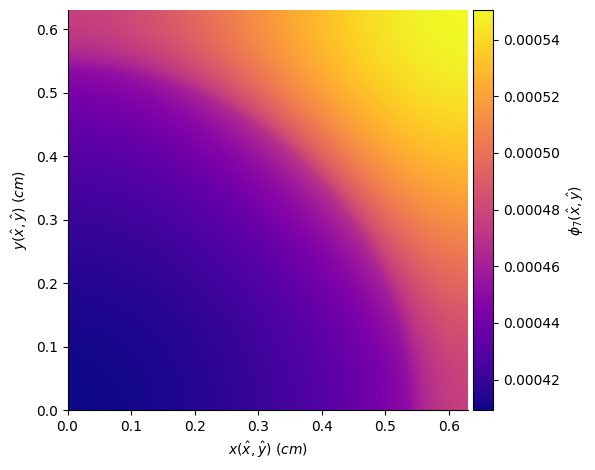

In [9]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(rf"$\phi_{g + 1}" + r"(\hat{x}, \hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}.png", dpi=300, transparent=True)
    plt.show()

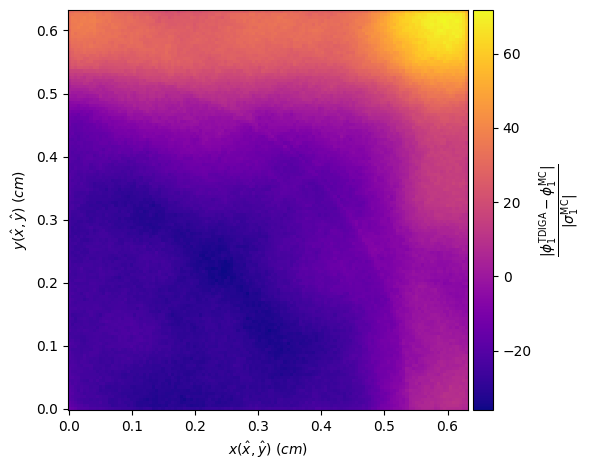

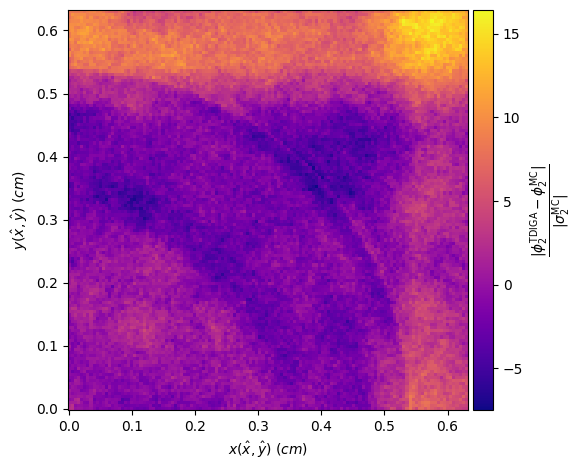

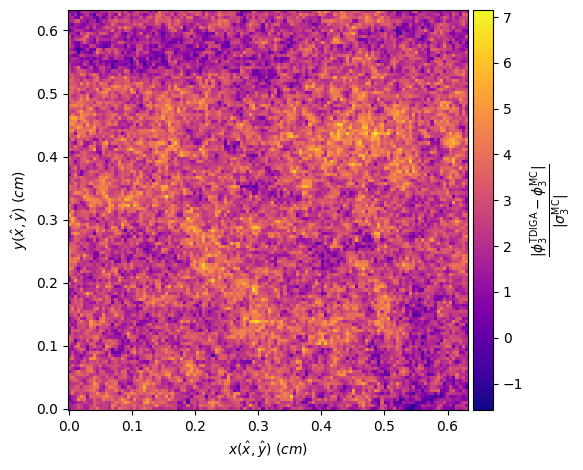

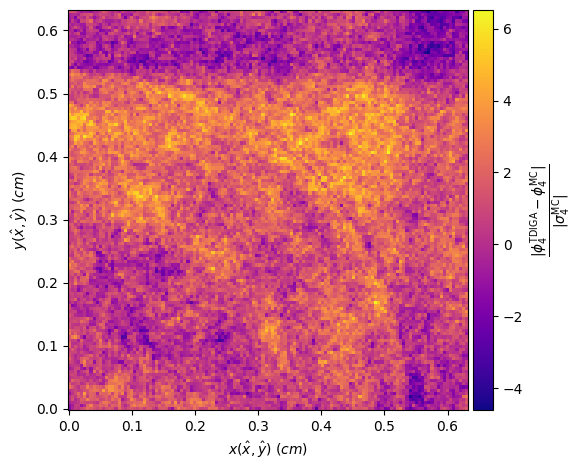

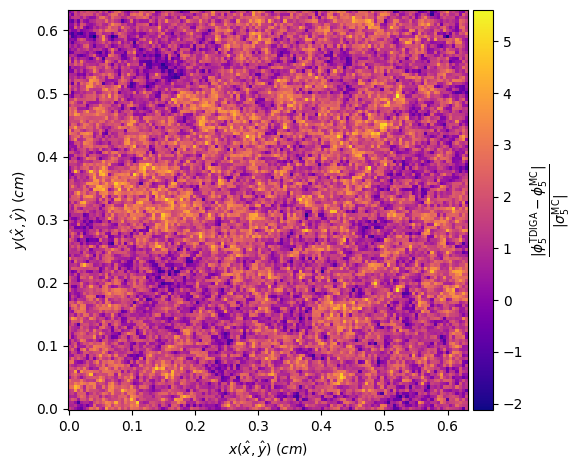

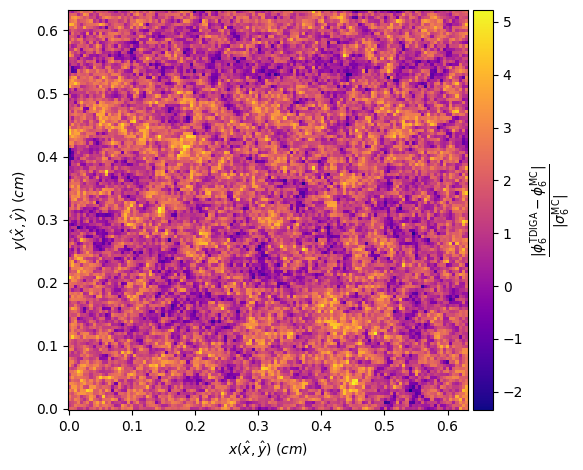

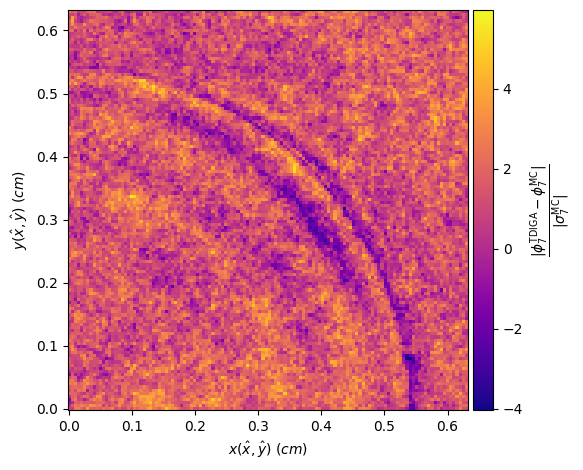

In [10]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, pitch / 2, phi_mc.shape[1]),
    np.linspace(0, pitch / 2, phi_mc.shape[2]),
)

# Calculate z-score within each voxel
z = (phi_avg - phi_mc) / phi_mc_stdev
stats = {
    "Group": list(range(1, xs_server.num_groups + 1)) + ["Total"],
    **{
        name: np.zeros(xs_server.num_groups + 1) 
        for name in 
        ["Minimum", "Q1", "Median", "Q2", "Maximum", "Mean", "L2 Error"]
    },
}

for g in range(xs_server.num_groups):
    # Plot z-score
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, z[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        r"$\frac{|\phi_" 
        + str(g + 1) + r"^{\text{TDIGA}} - \phi_" 
        + str(g + 1) + r"^{\text{MC}}|}{|\sigma_" 
        + str(g + 1) + r"^{\text{MC}}|}$",
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_zscore.png", dpi=300, transparent=True)
    plt.show()

    # Get some stats
    stats["Minimum"][g] = np.min(z[g,])
    stats["Q1"][g] = np.percentile(z[g,], 25)
    stats["Median"][g] = np.median(z[g,])
    stats["Q2"][g] = np.percentile(z[g,], 75)
    stats["Maximum"][g] = np.max(z[g,])
    stats["Mean"][g] = np.mean(z[g,])

stats["Minimum"][-1] = np.min(z)
stats["Q1"][-1] = np.percentile(z, 25)
stats["Median"][-1] = np.median(z)
stats["Q2"][-1] = np.percentile(z, 75)
stats["Maximum"][-1] = np.max(z)
stats["Mean"][-1] = np.mean(z)

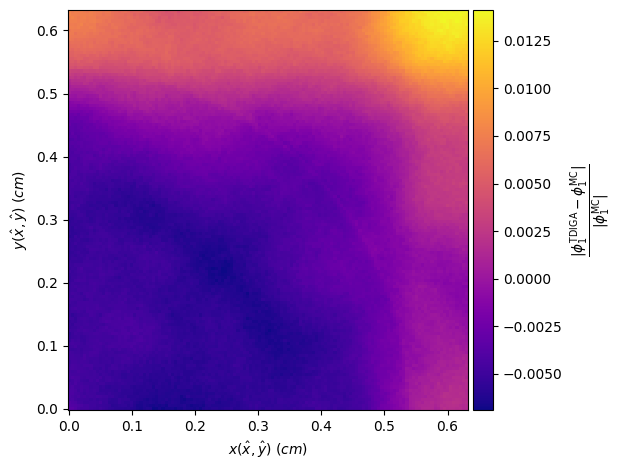

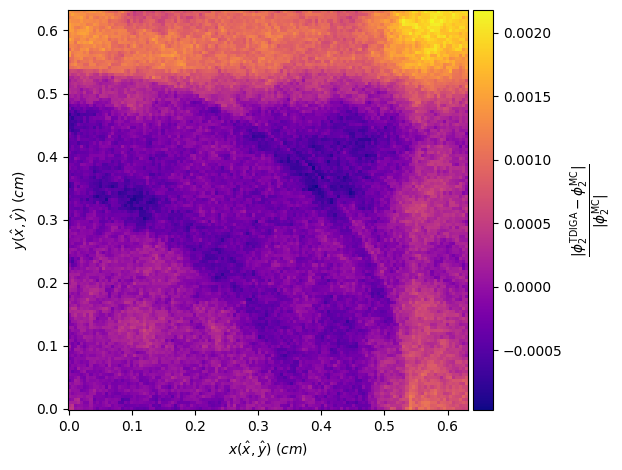

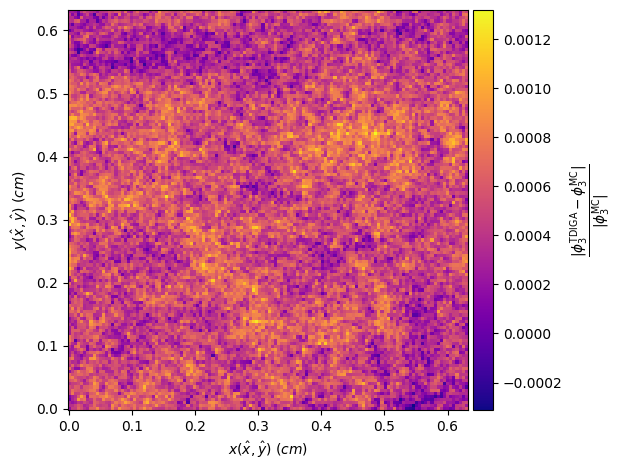

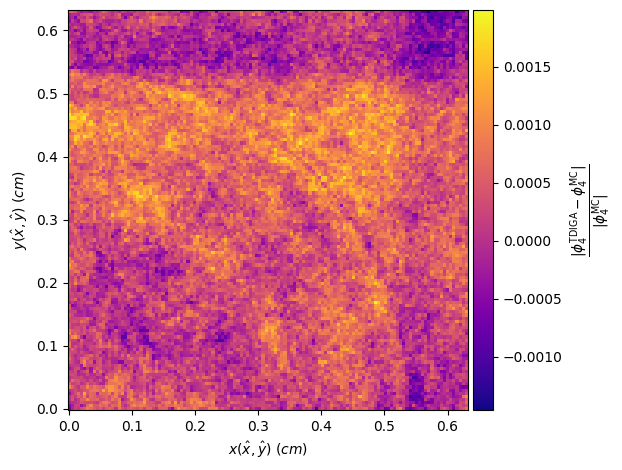

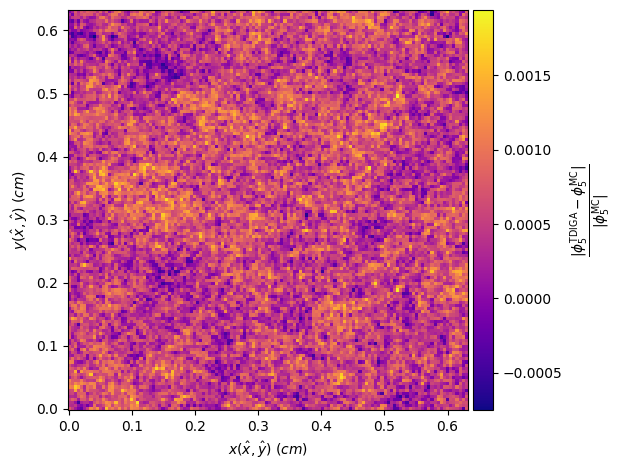

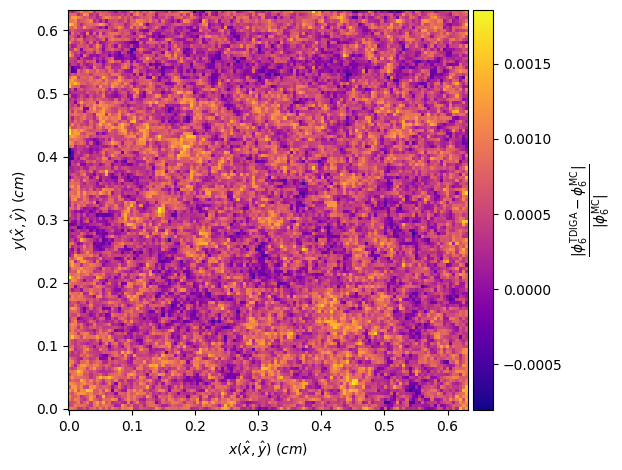

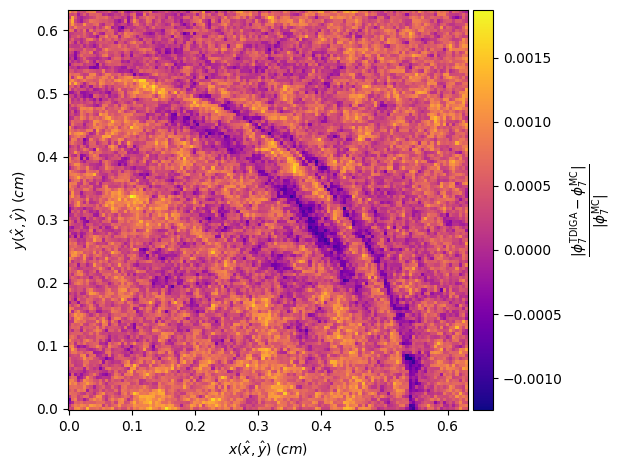

,Group,Minimum,Q1,Median,Q2,Maximum,Mean,L2 Error
0,1,-36.079512,-25.849189,-12.842711,9.489811,71.761061,-5.735075,0.004741
1,2,-7.522556,-1.891189,-0.133920,2.814866,16.420524,0.999699,0.000551
2,3,-1.587373,1.974702,2.710338,3.435503,7.153838,2.703866,0.000548
3,4,-4.622175,0.245657,1.258651,2.327621,6.517826,1.263681,0.000612
4,5,-2.130288,0.883350,1.568708,2.236507,5.606021,1.568213,0.000660
5,6,-2.355570,0.742014,1.467509,2.172196,5.225709,1.462911,0.000604
6,7,-4.046114,0.609733,1.365177,2.119479,5.972092,1.336016,0.000549
7,Total,-36.079512,0.127128,1.454973,2.589309,71.761061,0.514187,0.004955


In [11]:
relative_error = (phi_avg - phi_mc) / phi_mc

for g in range(xs_server.num_groups):
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, relative_error[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        r"$\frac{|\phi_" 
        + str(g + 1) + r"^{\text{TDIGA}} - \phi_" 
        + str(g + 1) + r"^{\text{MC}}|}{|\phi_" 
        + str(g + 1) + r"^{\text{MC}}|}$",
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_error.png", dpi=300, transparent=True)
    plt.show()

    # Calculate L2-error
    stats["L2 Error"][g] = (
        np.linalg.norm((phi_avg[g,] - phi_mc[g,]).flatten(), 2) 
        / np.linalg.norm(phi_mc[g,].flatten(), 2)
    )

# Calculate L2-error
stats["L2 Error"][-1] = (
    np.linalg.norm(stats["L2 Error"][:-1], 2)
)
pd.DataFrame(stats)